Dataset Shape: (8807, 12)

Columns:
 Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Missing Values:

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate Rows: 0


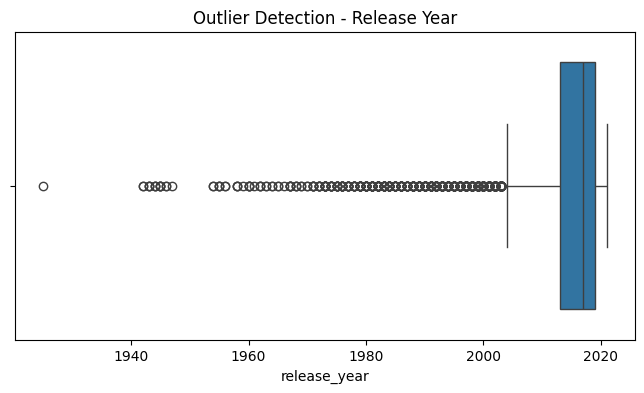


Outliers Removed Successfully


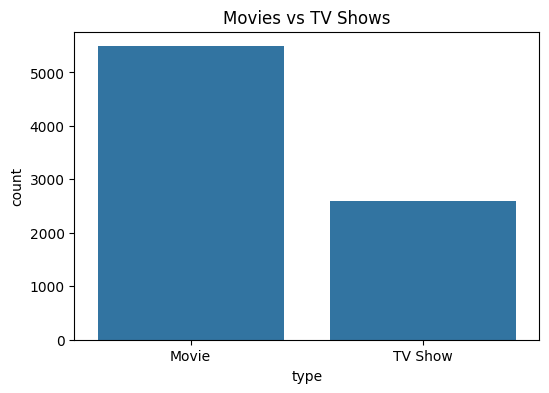

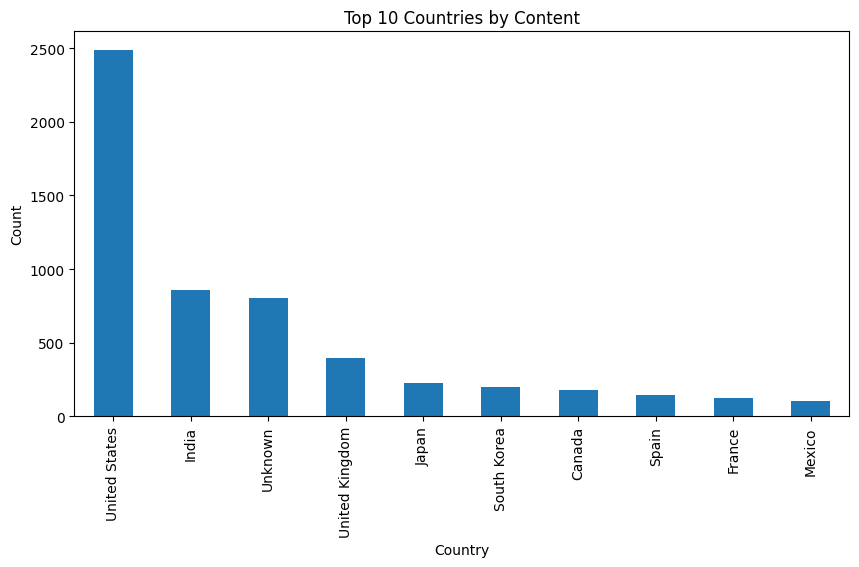

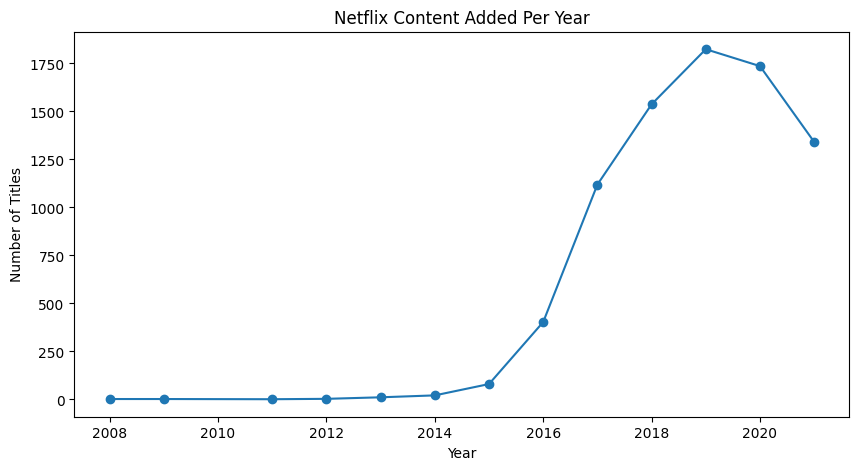

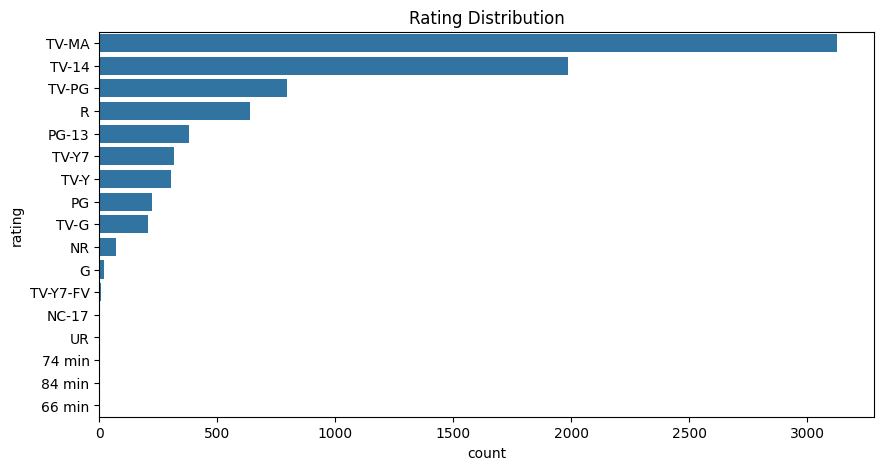

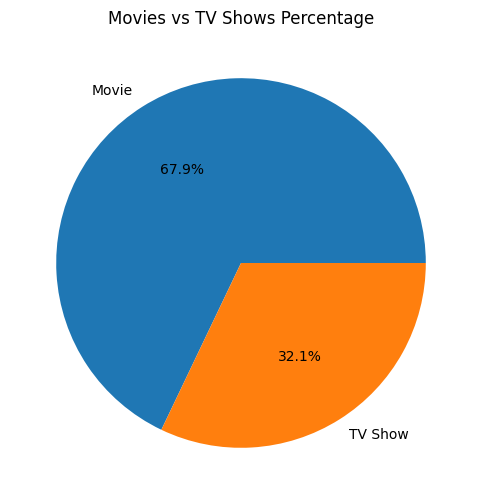

In [ ]:



# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('/content/netflix_titles.csv')


# 1. DATA INSPECTION

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n")
print(df.isnull().sum())


# 2. HANDLE MISSING VALUES

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

if 'rating' in df.columns:
    df['rating'] = df['rating'].fillna(df['rating'].mode()[0])


# 3. REMOVE DUPLICATES

duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

df.drop_duplicates(inplace=True)


# 4. DATE PROCESSING

df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce',
    format='mixed'
)

df.dropna(subset=['date_added'], inplace=True)

df['year_added'] = df['date_added'].dt.year


# 5. OUTLIER DETECTION & HANDLING
plt.figure(figsize=(8,4))
sns.boxplot(x=df['release_year'])
plt.title("Outlier Detection - Release Year")
plt.show()

Q1 = df['release_year'].quantile(0.25)
Q3 = df['release_year'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['release_year'] >= lower) &
    (df['release_year'] <= upper)
]

print("\nOutliers Removed Successfully")


# 6. VISUALIZATION REPORTS
# Graph 1: Movies vs TV Shows
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

# Graph 2: Top 10 Countries
plt.figure(figsize=(10,5))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries by Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

# Graph 3: Content Added Per Year
plt.figure(figsize=(10,5))
year_data = df['year_added'].value_counts().sort_index()

plt.plot(
    year_data.index,
    year_data.values,
    marker='o'
)

plt.title("Netflix Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

# Graph 4: Rating Distribution
plt.figure(figsize=(10,5))
sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)
plt.title("Rating Distribution")
plt.show()

# Graph 5: Pie Chart
plt.figure(figsize=(6,6))
type_count = df['type'].value_counts()

plt.pie(
    type_count,
    labels=type_count.index,
    autopct='%1.1f%%'
)

plt.title("Movies vs TV Shows Percentage")
plt.show()

# 7. SAVE CLEANED DATASET

df.to_csv(
    '/content/cleaned_netflix_dataset.csv',
    index=False
)

